In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('vgchartz-2024.csv')

In [3]:
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [5]:
dupli=df[df.duplicated()]
print(dupli)

Empty DataFrame
Columns: [img, title, console, genre, publisher, developer, critic_score, total_sales, na_sales, jp_sales, pal_sales, other_sales, release_date, last_update]
Index: []


In [6]:
df.isnull().sum()

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64

In [7]:
df.describe()

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
count,6678.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000
mean,7.220440,0.349113,0.264740,0.102281,0.149472,0.043041
std,1.457066,0.807462,0.494787,0.168811,0.392653,0.126643
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000
50%,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000
75%,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000


In [8]:
df.shape

(64016, 14)

<Axes: xlabel='critic_score', ylabel='Count'>

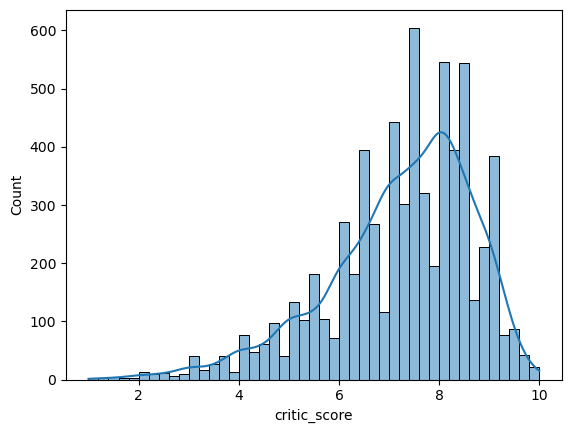

In [9]:
## Checking the outliers
sns.histplot(x='critic_score',data=df,kde=True)

Filling and heandling Null values

In [10]:

df['total_sales']=df['total_sales'].fillna(
    df.groupby('genre')['total_sales'].transform('median')
)
df['total_sales'] = df['total_sales'].fillna(df['total_sales'].median())

In [11]:
df.isnull().sum()

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales         0
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64

There is large number of null row and we can not delete this much of data so we will fill it with median.

In [12]:
df['critic_score']=df['critic_score'].fillna(
    df.groupby('genre')['critic_score'].transform('median')
)
df['critic_score'] = df['critic_score'].fillna(df['critic_score'].median())

In [13]:
df['na_sales']=df['na_sales'].fillna(
    df.groupby('genre')['na_sales'].transform('median')
)
df['na_sales'] = df['na_sales'].fillna(df['na_sales'].median())

df['na_sales']=df['na_sales'].fillna(
    df.groupby('genre')['na_sales'].transform('median')
)
df['na_sales'] = df['na_sales'].fillna(df['na_sales'].median())

df['jp_sales']=df['jp_sales'].fillna(
    df.groupby('genre')['jp_sales'].transform('median')
)
df['jp_sales'] = df['jp_sales'].fillna(df['jp_sales'].median())

df['pal_sales']=df['pal_sales'].fillna(
    df.groupby('genre')['pal_sales'].transform('median')
)
df['pal_sales'] = df['pal_sales'].fillna(df['pal_sales'].median())

df['other_sales']=df['other_sales'].fillna(
    df.groupby('genre')['other_sales'].transform('median')
)
df['other_sales'] = df['other_sales'].fillna(df['other_sales'].median())

In [14]:
df=df.drop('last_update',axis=1)

In [15]:
df=df.dropna(subset='release_date')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56965 entries, 0 to 64014
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           56965 non-null  object 
 1   title         56965 non-null  object 
 2   console       56965 non-null  object 
 3   genre         56965 non-null  object 
 4   publisher     56965 non-null  object 
 5   developer     56954 non-null  object 
 6   critic_score  56965 non-null  float64
 7   total_sales   56965 non-null  float64
 8   na_sales      56965 non-null  float64
 9   jp_sales      56965 non-null  float64
 10  pal_sales     56965 non-null  float64
 11  other_sales   56965 non-null  float64
 12  release_date  56965 non-null  object 
dtypes: float64(6), object(7)
memory usage: 6.1+ MB


In [17]:
## Spliting the Release date column
df['Year']=df['release_date'].str.split('-').str[0]
df['Month']=df['release_date'].str.split('-').str[1]
df['Date']=df['release_date'].str.split('-').str[2]

In [18]:
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,Year,Month,Date
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,2013,09,17
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2014,11,18
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,2002,10,28
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.0,15.86,9.06,0.06,5.33,1.42,2013-09-17,2013,09,17
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2015,11,06


In [19]:
df=df.drop('release_date',axis=1)

In [20]:
#EDA
## Which titles sold the most worldwide?
df['title'].unique()

array(['Grand Theft Auto V', 'Grand Theft Auto: Vice City',
       'Call of Duty: Black Ops 3', ..., 'Without Within 3',
       'Yoru, Tomosu', 'Yunohana SpRING! ~Mellow Times~'],
      shape=(36887,), dtype=object)

<Axes: xlabel='title', ylabel='total_sales'>

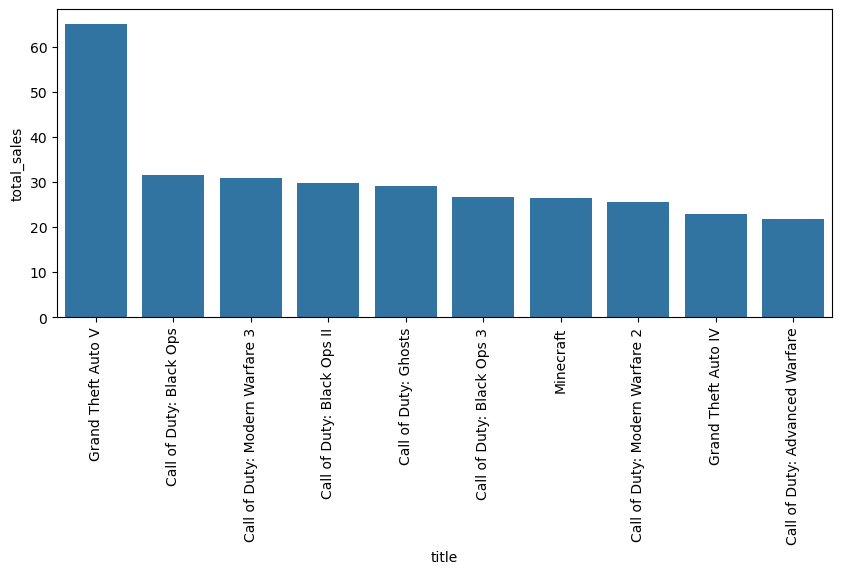

In [23]:
top = df.groupby('title')['total_sales'].sum().nlargest(10).reset_index()
plt.figure(figsize=(10,4))
plt.xticks(rotation=90)
sns.barplot(x='title',y='total_sales',data=top)

Most sold Game title are Geand Theft Auto,Call of Duty:Black Ops and Call of Duty: Modern Warfare 3

<Axes: xlabel='genre', ylabel='total_sales'>

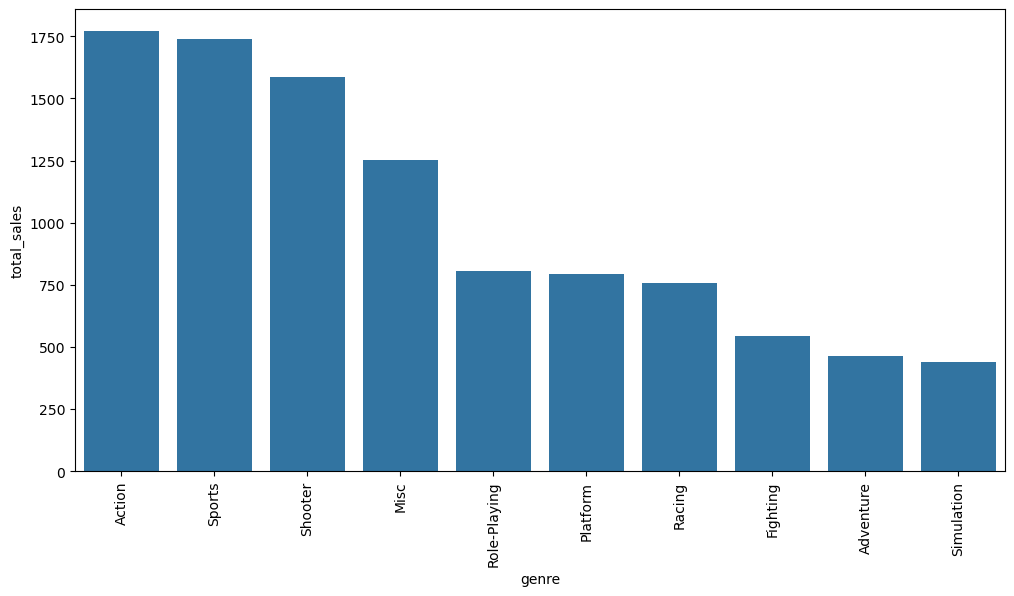

In [23]:
genre_top = df.groupby('genre')['total_sales'].sum().nlargest(10).reset_index()
plt.figure(figsize=(12,6))
plt.xticks(rotation=90)
sns.barplot(x='genre',y='total_sales',data=genre_top)

Action, Sports, and Shooter games have the highest total sales, making them the most popular genres.

In [24]:
df['Year'].unique()

array(['2013', '2014', '2002', '2015', '2011', '2010', '2018', '2012',
       '2009', '2017', '2001', '2008', '2016', '2007', '2005', '2003',
       '2004', '1999', '1996', '2006', '1997', '2000', '1981', '1989',
       '1994', '1998', '1995', '1993', '1990', '1988', '1982', '1983',
       '1986', '1992', '1987', '1977', '1991', '1985', '2019', '2020',
       '1984', '1980', '1978', '1979', '2022', '2023', '2021', '2024',
       '1971', '1975', '1973'], dtype=object)

([<matplotlib.axis.XTick at 0x167b354a8d0>,
 [Text(0.0, 0, '1971'),
  Text(2.0, 0, '1975'),
  Text(4.0, 0, '1978'),
  Text(6.0, 0, '1980'),
  Text(8.0, 0, '1982'),
  Text(10.0, 0, '1984'),
  Text(12.0, 0, '1986'),
  Text(14.0, 0, '1988'),
  Text(16.0, 0, '1990'),
  Text(18.0, 0, '1992'),
  Text(20.0, 0, '1994'),
  Text(22.0, 0, '1996'),
  Text(24.0, 0, '1998'),
  Text(26.0, 0, '2000'),
  Text(28.0, 0, '2002'),
  Text(30.0, 0, '2004'),
  Text(32.0, 0, '2006'),
  Text(34.0, 0, '2008'),
  Text(36.0, 0, '2010'),
  Text(38.0, 0, '2012'),
  Text(40.0, 0, '2014'),
  Text(42.0, 0, '2016'),
  Text(44.0, 0, '2018'),
  Text(46.0, 0, '2020'),
  Text(48.0, 0, '2022'),
  Text(50.0, 0, '2024')])

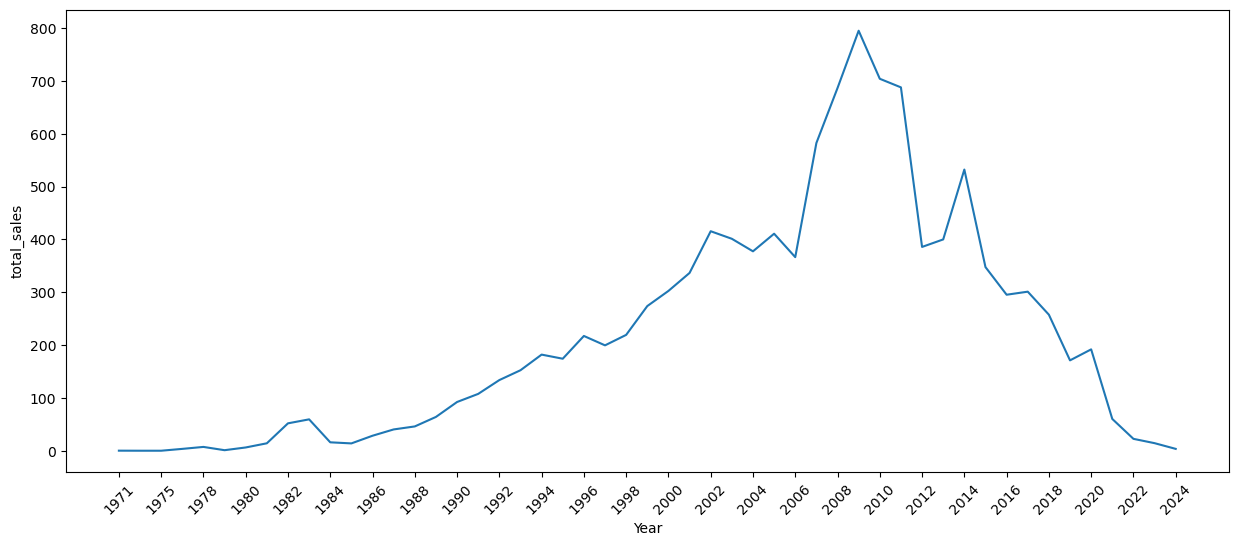

In [25]:
##Which year had the highest sales? Is the industry growing over time?
group_bySales=df.groupby('Year')['total_sales'].sum().reset_index()
plt.figure(figsize=(15,6))
sns.lineplot(x='Year',y='total_sales',data=group_bySales)
plt.xticks(group_bySales['Year'][::2],rotation=45)


From the above plot we can say that "The industry experienced strong growth from the 1990s, peaking around 2008–2010, followed by a noticeable decline, especially after 2015"

In [26]:
## Do any consoles seem to specialize in a particular genre?
df['console'].unique()

array(['PS3', 'PS4', 'PS2', 'X360', 'XOne', 'PC', 'PSP', 'Wii', 'PS',
       'DS', '2600', 'GBA', 'NES', 'XB', 'PSN', 'GEN', 'PSV', 'DC', 'N64',
       'SAT', 'SNES', 'GBC', 'GC', 'NS', '3DS', 'GB', 'WiiU', 'WS', 'VC',
       'NG', 'WW', 'SCD', 'PCE', 'XBL', '3DO', 'GG', 'OSX', 'Mob', 'PCFX',
       'Series', 'All', 'iOS', '5200', 'And', 'DSiW', 'Lynx', 'Linux',
       'MS', 'ZXS', 'ACPC', 'Amig', '7800', 'AJ', 'WinP', 'VB', 'Ouya',
       'NGage', 'AST', 'MSD', 'S32X', 'Int', 'XS', 'PS5', 'CV', 'OR',
       'C128', 'CDi', 'DSi', 'Arc', 'C64', 'BRW', 'FMT', 'MSX', 'GIZ',
       'ApII', 'Aco', 'BBCM', 'TG16', 'CD32'], dtype=object)

In [27]:
top_consoles = df['console'].value_counts().nlargest(5).index
top_genres = df['genre'].value_counts().nlargest(5).index

top_con_gen = df[
    (df['console'].isin(top_consoles)) &
    (df['genre'].isin(top_genres))
]

<Axes: xlabel='console', ylabel='count'>

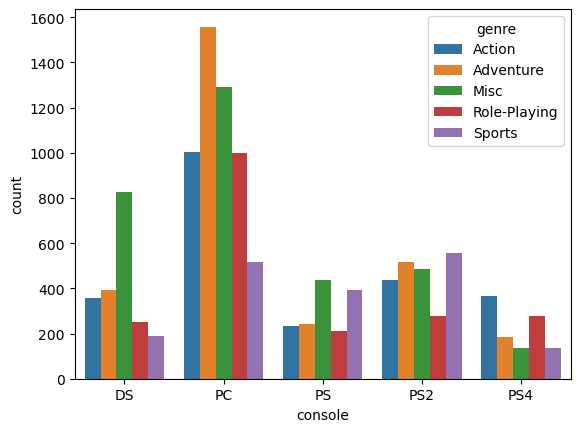

In [28]:
group_con_gen = top_con_gen.groupby(['console','genre']).size().reset_index(name='count')

sns.barplot(data=group_con_gen, x='console', y='count', hue='genre')

No console is exclusively specialized in one genre, but:

PC → Adventure (and overall high across genres)

DS → Misc

PS/PS2 → some tilt toward Sports/Misc

PS4 → more Action-focused

In [29]:
## What titles are popular in one region but flop in another?
top = df.groupby('title')['total_sales'].sum().nlargest(10).index
df_top=df[df['title'].isin(top)]
grouped=df_top.groupby('title')[['na_sales','jp_sales','pal_sales','other_sales']].sum().reset_index()

<Axes: xlabel='title', ylabel='Sales'>

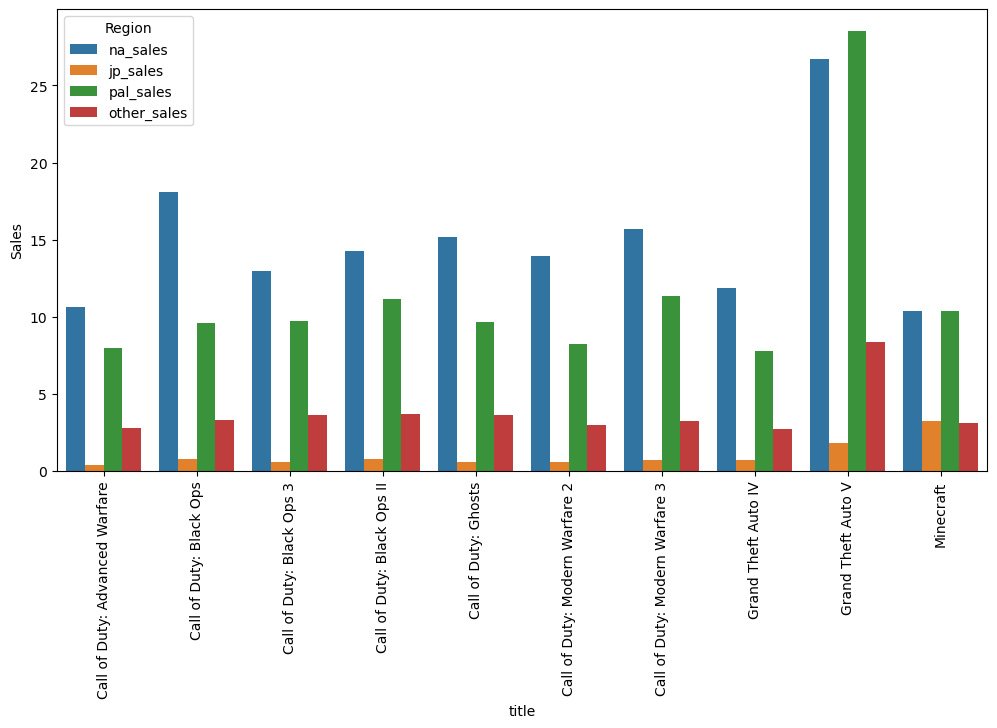

In [30]:
grouped_melted = grouped.melt(
    id_vars='title',
    var_name='Region',
    value_name='Sales'
)
plt.figure(figsize=(12,6))
plt.xticks(rotation=90)
sns.barplot(x='title',y='Sales',hue='Region',data=grouped_melted)

Call of Duty series and Grand Theft Auto V have very high sales in North America, European & African regions but significantly lower sales in Japan. This indicates that these titles are highly popular in Western markets but relatively less successful in the Japanese market.

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56965 entries, 0 to 64014
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           56965 non-null  object 
 1   title         56965 non-null  object 
 2   console       56965 non-null  object 
 3   genre         56965 non-null  object 
 4   publisher     56965 non-null  object 
 5   developer     56954 non-null  object 
 6   critic_score  56965 non-null  float64
 7   total_sales   56965 non-null  float64
 8   na_sales      56965 non-null  float64
 9   jp_sales      56965 non-null  float64
 10  pal_sales     56965 non-null  float64
 11  other_sales   56965 non-null  float64
 12  Year          56965 non-null  object 
 13  Month         56965 non-null  object 
 14  Date          56965 non-null  object 
dtypes: float64(6), object(9)
memory usage: 7.0+ MB


<Axes: xlabel='total_sales', ylabel='critic_score'>

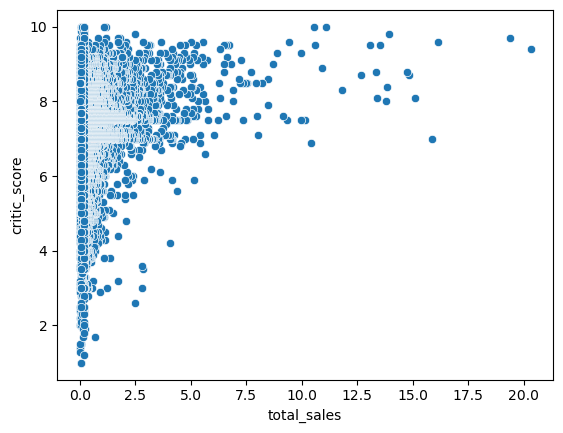

In [34]:
tip=df[['critic_score','total_sales']]
tip.corr()
sns.scatterplot(x='total_sales',y='critic_score',data=tip)

There is a weak positive relationship between critic score and sales. Games with higher scores often sell more, but many high-scoring games still have low sales. So, good reviews help, but they don’t guarantee high sales.

Final Insight: The industry peaked around 2008–2010, with Action, Sports, and Shooter genres leading sales. Top games like GTA V and Call of Duty dominate, especially in Western regions, while Japan shows lower sales for these titles. Critic scores have a weak positive impact on sales. 

# Project Title

A brief description of what this project does and who it's for

#  Video Game Sales Dashboard

### Dashboard/Notebook Link : [Add your GitHub or Notebook link here]

---

##  Problem Statement

This project helps analyze video game sales data to understand market trends, player preferences, and regional performance. It helps identify which genres, consoles, and games are most successful and how critic scores influence sales.

Through this analysis, we can determine:

* Which genres are most popular
* Which regions contribute the most to sales
* Whether critic scores impact game success
* Which games perform differently across regions

Since certain genres dominate the market and regional differences exist, companies can use these insights to better target audiences and improve game development strategies.

---

##  Steps Followed

* Step 1 : Loaded dataset into Python (CSV file).
* Step 2 : Performed data cleaning:

  * Checked missing values
  * Handled null values
  * Verified data types
* Step 3 : Conducted exploratory data analysis (EDA).
* Step 4 : Created new aggregated columns like total sales where required.
* Step 5 : Grouped data by:

  * Genre
  * Console
  * Year
  * Region
* Step 6 : Filtered top 10 games based on total sales for focused analysis.
* Step 7 : Compared regional sales (NA, EU, JP, Others).
* Step 8 : Created multiple visualizations:

  * Bar charts
  * Line plots
  * Heatmaps
  * Scatter plots
* Step 9 : Analyzed relationship between critic score and total sales.
* Step 10 : Interpreted results to extract insights.

---

### Key Analysis Performed

#### 1. Top Games Analysis (Sales by Title)
* Compared total sales across different game titles
* Found that:
  * Grand Theft Auto, Call of Duty: Black Ops, and Call of Duty: Modern Warfare 3 are the highest-selling game titles

<img width="1182" height="805" alt="Image" src="https://github.com/user-attachments/assets/9e3195be-adbc-4ae3-a0fb-2683a4f05173" />

#### 2. Genre Analysis

* Compared total sales across genres
* Found that:

  * Action, Sports, Shooter → highest sales
  * Adventure, Simulation → lowest sales

<img width="1014" height="596" alt="Image" src="https://github.com/user-attachments/assets/fa8ea368-8723-4164-841b-d6ca9ca48af4" />
---

#### 3. Sales Trend Analysis

* Analyzed sales trends over time
Found that:
 * The gaming industry grew steadily from the 1990s    * Reached its peak during 2008–2010
 * Then declined significantly in later years

<img width="1238" height="546" alt="Image" src="https://github.com/user-attachments/assets/4caed4b1-2cae-455c-807f-b3272028059e" />
---

#### 4. Regional Sales Analysis

* Compared top 10 games and there performance across regions
* Found that many top games perform well in Western regions but poorly in Japan

<img width="1238" height="546" alt="Image" src="https://github.com/user-attachments/assets/4caed4b1-2cae-455c-807f-b3272028059e" />
---

#### 5. Console vs Genre Analysis

* Analyzed how consoles perform across genres
* Found that most consoles support multiple genres with slight preferences

<img width="580" height="432" alt="Image" src="https://github.com/user-attachments/assets/355fa63a-1575-4b54-80fb-6a044ca3d257" />
---

### 6. Sales vs Critic Score

* Used scatter plot and correlation
* Found:

  * Weak positive relationship
  * High ratings do not always guarantee high sales

<img width="997" height="728" alt="Image" src="https://github.com/user-attachments/assets/e7671568-62e8-480f-9f58-46b44372e43c" />

---

##  Visualizations Used

* Bar Chart → Genre & regional Sales comparison
* Line Plot → Sales trends over time
* Scatter Plot → Sales vs critic score

## 🚀 Conclusion

The gaming industry is driven by popular genres like Action and Sports, with strong dominance from Western markets. While critic reviews influence success to some extent, they are not the only factor affecting sales. Regional preferences play a key role in determining a game's success.

---

## 📁 How to Run

1. Clone the repository
2. Open the Jupyter Notebook
3. Run all cells

---

## ✍️ Author

[Your Name]

---
